In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, 
    confusion_matrix, RocCurveDisplay, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, f1_score, precision_recall_curve
)

#Boosting
import xgboost as xgb


In [2]:
RANDOM_STATE = 101
DATA_DIR = '../data/Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_DIR)

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(['customerID', 'Churn'], axis=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


###  Preprocesamiento dentro del pipeline (evita leakage y es reusable para los experimentos de boosting más adelante)

In [5]:
# ---------------------------------------------------------------------
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
 
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])

/var/folders/ym/g3zmjphd5kj9rmvdfmq2bpgr0000gn/T/ipykernel_84496/1362353912.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


## Regresión logística

In [6]:
pipe = Pipeline([('preprocessor', preprocessor),
                 ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))

])

param_grid = [
    {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__l1_ratio": [0]  
    },
    {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__solver": ["liblinear", "saga"],
        "clf__l1_ratio": [1]  
    },
    {
       
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__l1_ratio": [0.2, 0.5, 0.8],
        "clf__solver": ["saga"]
    }
]

In [7]:
grid_model = GridSearchCV(pipe, param_grid=param_grid, cv = 5, n_jobs=-1, scoring='average_precision')
grid_model.fit(X_train, y_train)

/opt/homebrew/Caskroom/miniforge/base/envs/churn_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/churn_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/churn_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/churn_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/churn_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarni

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__C': [0.01, 0.1, ...], 'clf__l1_ratio': [0], 'clf__solver': ['lbfgs', 'liblinear']}, {'clf__C': [0.01, 0.1, ...], 'clf__l1_ratio': [1], 'clf__solver': ['liblinear', 'saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-valid

In [8]:
print("Best params:", grid_model.best_params_)
print("Best CV score (average_precision):", grid_model.best_score_)

Best params: {'clf__C': 1, 'clf__l1_ratio': 1, 'clf__solver': 'saga'}
Best CV score (average_precision): 0.6532623144978988


### Evaluación del test

In [9]:
best_model = grid_model.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [10]:
auc_test = roc_auc_score(y_test, y_prob)
ap_test = average_precision_score(y_test, y_prob)
f1_churn = f1_score(y_test, y_pred, pos_label=1)
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

In [11]:
print("AUC test:", auc_test)
print("Average Precision test:", ap_test)
print("F1 (Churn=Yes):", f1_churn)
print(classification_report(y_test, y_pred))
print(cm)

AUC test: 0.8415548917798219
Average Precision test: 0.6664263670219793
F1 (Churn=Yes): 0.5855855855855856
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.80      1407

[[936  97]
 [179 195]]


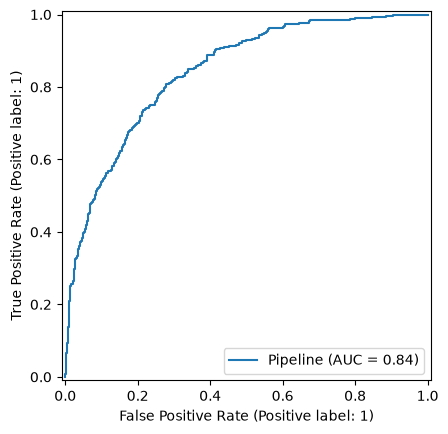

In [12]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)


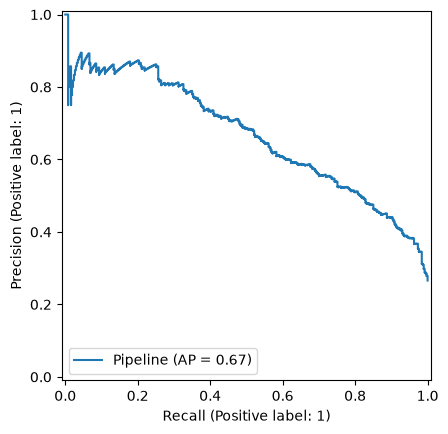

In [13]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)


## Random Forest

In [14]:
pipe_rf = Pipeline([('preporcessor', preprocessor), ('clf', RandomForestClassifier(random_state=RANDOM_STATE))])

param_grid_rf = {
    "clf__n_estimators": [100, 200, 400],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__class_weight": [None, "balanced"]
}

In [15]:
grid_rf = GridSearchCV(pipe_rf, param_grid=param_grid_rf, cv = 5 , n_jobs=-1, scoring='average_precision')
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=101))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__class_weight': [None, 'balanced'], 'clf__max_depth': [None, 5, ...], 'clf__min_samples_leaf': [1, 5, ...], 'clf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [16]:
print("Best params:", grid_rf.best_params_)
print("Best CV score (average_precision):", grid_rf.best_score_)

Best params: {'clf__class_weight': None, 'clf__max_depth': 10, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Best CV score (average_precision): 0.6646476150371383


### Evaluación del test

In [17]:
best_model_rf = grid_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)
y_prob_rf = best_model_rf.predict_proba(X_test)[:, 1]

In [18]:
auc_test = roc_auc_score(y_test, y_prob_rf)
ap_test = average_precision_score(y_test, y_prob_rf)
f1_churn = f1_score(y_test, y_pred_rf, pos_label=1)
report = classification_report(y_test, y_pred_rf, output_dict=True)
cm = confusion_matrix(y_test, y_pred_rf)

In [19]:
print("AUC test:", auc_test)
print("Average Precision test:", ap_test)
print("F1 (Churn=Yes):", f1_churn)
print(classification_report(y_test, y_pred))
print(cm)

AUC test: 0.8394104187481557
Average Precision test: 0.6702872303860222
F1 (Churn=Yes): 0.5851393188854489
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.80      1407

[[950  83]
 [185 189]]


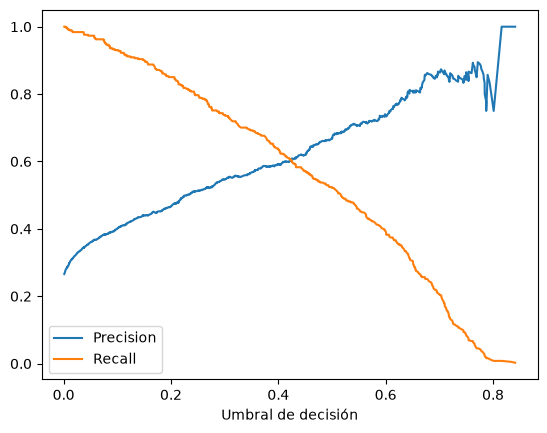

In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Umbral de decisión")
plt.legend()
plt.show()


## Boosting

In [21]:
pipe_xgb = Pipeline([('preprocessor', preprocessor),
                     ('clf', xgb.XGBClassifier(random_state = RANDOM_STATE, eval_metric = 'logloss'))
])

param_grid_xgb = {
    "clf__n_estimators": [100, 300, 500],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.7, 0.9, 1.0],
    "clf__scale_pos_weight": [1, (y_train==0).sum()/(y_train==1).sum()]  # maneja desbalance
}


In [22]:
grid_xgb = GridSearchCV(pipe_xgb, param_grid=param_grid_xgb, cv = 5 , n_jobs=-1, scoring='average_precision')
grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__learning_rate': [0.01, 0.05, ...], 'clf__max_depth': [3, 5, ...], 'clf__n_estimators': [100, 300, ...], 'clf__scale_pos_weight': [1, np.float64(2.762541806020067)], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated sco

In [23]:
print("Best params:", grid_xgb.best_params_)
print("Best CV score (average_precision):", grid_xgb.best_score_)

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__scale_pos_weight': 1, 'clf__subsample': 0.7}
Best CV score (average_precision): 0.6668707981754621


### Evaluación test

In [24]:
best_model_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

In [25]:
auc_test = roc_auc_score(y_test, y_prob_xgb)
ap_test = average_precision_score(y_test, y_prob_xgb)
f1_churn = f1_score(y_test, y_pred_xgb, pos_label=1)
report = classification_report(y_test, y_pred_xgb, output_dict=True)
cm = confusion_matrix(y_test, y_pred_xgb)

In [26]:
print("AUC test:", auc_test)
print("Average Precision test:", ap_test)
print("F1 (Churn=Yes):", f1_churn)
print(classification_report(y_test, y_pred))
print(cm)

AUC test: 0.8453468688364196
Average Precision test: 0.6750469842571858
F1 (Churn=Yes): 0.5991058122205664
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.80      1407

[[937  96]
 [173 201]]


## Al introducir Random Forest, observamos un trade-off sumamente interesante para el negocio. Aunque la Regresión Logística mantiene una capacidad de discriminación global ligeramente superior en todo el espectro (AUC = 0.8415), Random Forest optimiza la precisión en la ventana de alto riesgo, alcanzando un Average Precision del 67.03% y reduciendo los falsos positivos en un 14.4% (de 97 a 83). Esto demuestra que la estructura basada en árboles segmenta de forma más limpia a los usuarios con mayor probabilidad de abandono, ofreciendo un modelo óptimo si el objetivo comercial es maximizar el retorno de inversión (ROI) por cada campaña de retención ejecutada. Sin embargo, un modelo de regresión logística con regularización elasticnet da unos resultados muy similares, esto sugiere que el dataset no tiene señal no lineal compleja adicional que explotar.